<a href="https://colab.research.google.com/github/dashsumit/Projects/blob/main/Cat_Dog_Image_Classifiaction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import tensorflow as tf
from tensorflow import keras
from keras import layers,Sequential
from keras.layers import Dense,Conv2D,MaxPooling2D,Flatten,BatchNormalization,Dropout

In [3]:
!nvidia-smi

Sat Dec  6 15:57:10 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   41C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [4]:
##  using generators from keras
##  which helps to load large amount of data in batch

train_ds = keras.utils.image_dataset_from_directory(
    directory='/content/drive/MyDrive/Machine Learning(Python)/ML_Projects/Image_Datasets/Cat-Dog/train', # Corrected path
    labels="inferred",
    label_mode="int",
    batch_size=32,
    image_size=(256, 256),
    class_names=['Cat', 'Dog']
)




Found 25000 files belonging to 2 classes.


In [5]:
test_ds = keras.utils.image_dataset_from_directory(
    directory='/content/drive/MyDrive/Machine Learning(Python)/ML_Projects/Image_Datasets/Cat-Dog/test',
    labels="inferred",
    label_mode="int", # Changed to 'int' for consistency with train_ds and binary classification
    batch_size=32,
    image_size=(256, 256),
    # class_names=['Cat', 'Dog'] # Added class_names for explicit mapping
)

Found 12500 files belonging to 1 classes.


### In your current setup, since you are doing binary classification (Cat vs. Dog) and your final layer has activation='sigmoid' with loss='binary_crossentropy', using label_mode='int' is appropriate. If you were to have more than two classes and used categorical_crossentropy as your loss, you would typically use label_mode='categorical' and have a final Dense layer with activation='softmax'.

In [6]:
# # image has been stored in numpy array
# the problem is the numpy arrays value is 0 to 255
# so we need to range it between 0 and 1
# so we have to perform normalizations here

def process(image,label=None):
  image = tf.cast(image/255. ,tf.float32)
  if label is not None:
    return image,label
  else:
    return image

train_ds= train_ds.map(process)
test_ds= test_ds.map(process)

# CNN Model
## CNN stands for Convolutional Neural Network —
## a special type of deep learning model designed to work with images (and sometimes videos or signals).

## It’s one of the most powerful models for image classification, object detection, and recognition tasks.

In [12]:
model = Sequential()

model.add(Conv2D(32,kernel_size=(3,3),padding='valid',activation='relu',input_shape=(256,256,3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(64,kernel_size=(3,3),padding='valid',activation='relu',input_shape=(256,256,3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(128,kernel_size=(3,3),padding='valid',activation='relu',input_shape=(256,256,3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Flatten())

model.add(Dense(128,activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(64,activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(32,activation='relu'))
model.add(Dropout(0.1))
# model.add(Dense(16,activation='relu'))
# model.add(Dropout(0.1))
model.add(Dense(1,activation='sigmoid'))


In [13]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 254, 254, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 125, 125, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 60, 60, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,850,241 (56.65 MB)

 Trainable params: 14,849,793 (56.65 MB)

 Non-trainable params: 448 (1.75 KB)

In [14]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [15]:
history = model.fit(train_ds,epochs=5,validation_data=test_ds)

Epoch 1/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 4170s 5s/step - accuracy: 0.5491 - loss: 2.0683 - val_accuracy: 0.6242 - val_loss: 1.0249
Epoch 2/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 154s 197ms/step - accuracy: 0.6421 - loss: 0.6368 - val_accuracy: 0.5244 - val_loss: 1.1941
Epoch 3/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 169s 217ms/step - accuracy: 0.7313 - loss: 0.5320 - val_accuracy: 0.6118 - val_loss: 0.8344
Epoch 4/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 162s 208ms/step - accuracy: 0.7848 - loss: 0.4571 - val_accuracy: 0.6518 - val_loss: 0.6046
Epoch 5/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 194s 249ms/step - accuracy: 0.8233 - loss: 0.3876 - val_accuracy: 0.4794 - val_loss: 1.0922


##The most important observation is that while your model's performance on the training data improved significantly (high accuracy, low loss), its performance on the validation data (unseen data) did not improve and its loss increased substantially. This is a classic sign of overfitting. Your model has learned the training data too well, including its noise and specific patterns, and is failing to generalize to new data.

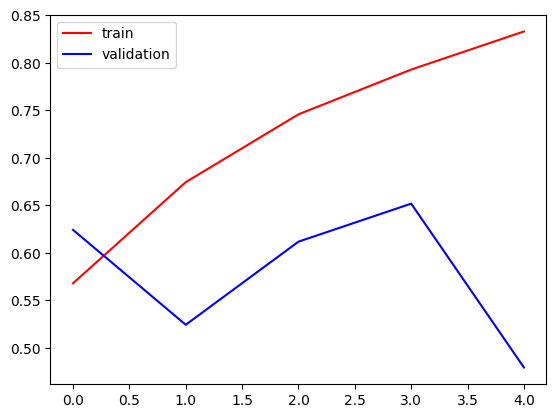

In [16]:
plt.plot(history.history['accuracy'],color='red',label='train')
plt.plot(history.history['val_accuracy'],color='blue',label='validation')
plt.legend()
plt.show()

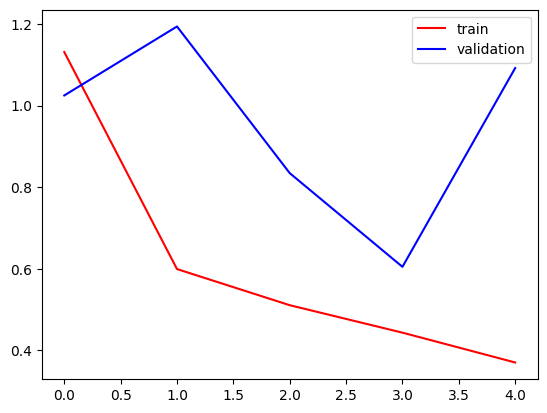

In [17]:
plt.plot(history.history['loss'],color='red',label='train')
plt.plot(history.history['val_loss'],color='blue',label='validation')
plt.legend()
plt.show()

##Prediction

In [18]:
import cv2

In [25]:
test_img=cv2.imread('/content/drive/MyDrive/Machine Learning(Python)/ML_Projects/Image_Datasets/Cat-Dog/kutu.jpg')

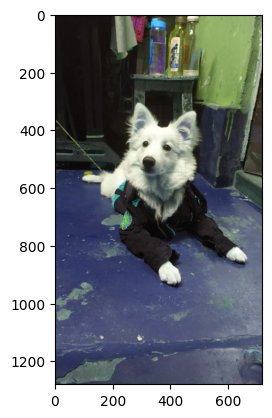

In [26]:
plt.imshow(test_img)

In [27]:
test_img.shape

(1280, 719, 3)

In [28]:
test_img=cv2.resize(test_img,(256,256))

In [55]:
test_input=test_img.reshape((1,256,256,3))
#test_input = test_input / 255.

In [56]:
model.predict(test_input)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


array([[1.]], dtype=float32)

#0 is Cat
# 1 is Dog

In [59]:
test_img2=cv2.imread('/content/drive/MyDrive/Machine Learning(Python)/ML_Projects/Image_Datasets/Cat-Dog/mini.jpg')

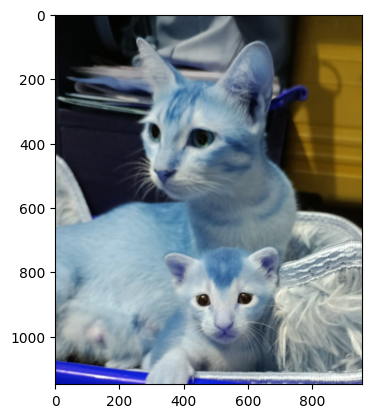

In [60]:
plt.imshow(test_img2)

In [61]:
test_img2.shape

(1149, 954, 3)

In [62]:
test_img2=cv2.resize(test_img,(256,256))

In [63]:
test_input2=test_img2.reshape((1,256,256,3))
test_input2 = test_input2 / 255.

In [64]:
model.predict(test_input2)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


array([[0.36866704]], dtype=float32)